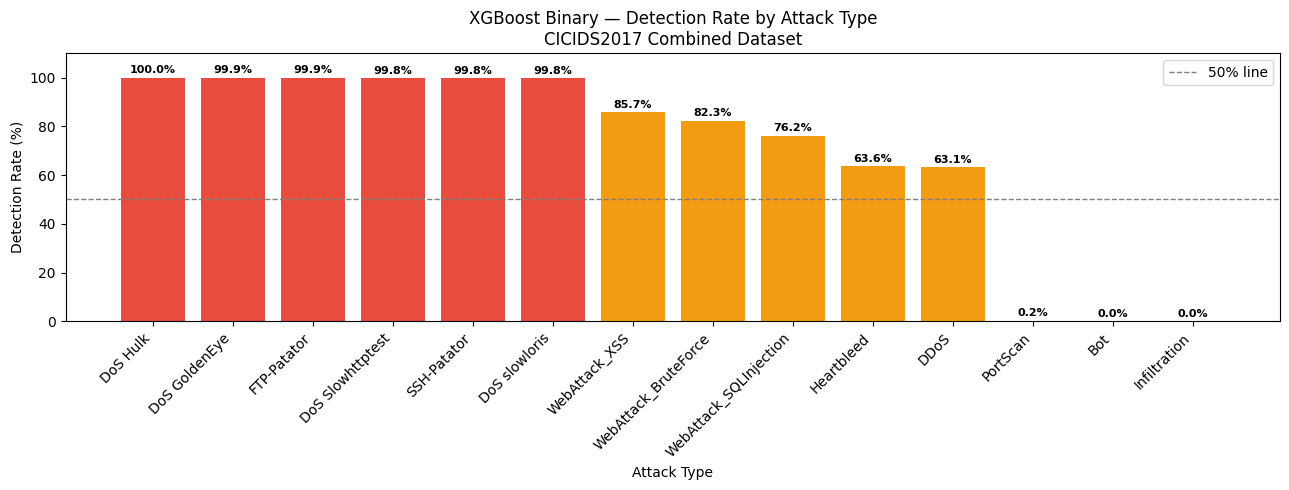

                true_label   Total  Detected  Detection Rate %
3                 DoS Hulk  230124    230120             100.0
2            DoS GoldenEye   10293     10285              99.9
6              FTP-Patator    7935      7930              99.9
4         DoS Slowhttptest    5499      5490              99.8
10             SSH-Patator    5897      5888              99.8
5            DoS slowloris    5796      5785              99.8
13           WebAttack_XSS     652       559              85.7
11    WebAttack_BruteForce    1507      1241              82.3
12  WebAttack_SQLInjection      21        16              76.2
7               Heartbleed      11         7              63.6
1                     DDoS  128025     80775              63.1
9                 PortScan  158804       327               0.2
0                      Bot    1956         0               0.0
8             Infiltration      36         0               0.0


In [1]:
import sys
import os
import numpy as np

sys.path.append(r"E:\UWI\DOUEN\Douen")

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import xgboost

from src.config.settings import CICIDS_OUTPUT, XGBOOST_BINARY_PATH

# -----------------------------
# Load combined dataset and model
# -----------------------------
combined_df = pd.read_parquet(CICIDS_OUTPUT)
model = joblib.load(XGBOOST_BINARY_PATH)

# -----------------------------
# Clean labels to match your preprocess naming
# -----------------------------
combined_df["Label"] = combined_df["Label"].astype(str).str.strip()
combined_df["Label"] = combined_df["Label"].replace({
    "Web Attack – Brute Force": "WebAttack_BruteForce",
    "Web Attack - Brute Force": "WebAttack_BruteForce",
    "Web Attack � Brute Force": "WebAttack_BruteForce",
    "Web Attack – XSS": "WebAttack_XSS",
    "Web Attack - XSS": "WebAttack_XSS",
    "Web Attack � XSS": "WebAttack_XSS",
    "Web Attack – Sql Injection": "WebAttack_SQLInjection",
    "Web Attack - Sql Injection": "WebAttack_SQLInjection",
    "Web Attack � Sql Injection": "WebAttack_SQLInjection"
})

# -----------------------------
# Build feature matrix like training did
# -----------------------------
y_true = combined_df["Label"].copy()

X = combined_df.drop(columns=["Label", "dataset", "source_file"], errors="ignore")
X = X.select_dtypes(include=[np.number]).copy()
X = X.fillna(0)

# -----------------------------
# Predict with XGBoost binary
# -----------------------------
y_pred = model.predict(X)

results = pd.DataFrame({
    "true_label": y_true,
    "predicted_attack": y_pred
})

# Only real attacks for per-attack chart
attack_df = results[results["true_label"] != "BENIGN"].copy()

# -----------------------------
# Detection rate by attack type
# -----------------------------
summary = (
    attack_df.groupby("true_label")["predicted_attack"]
    .agg(Total="count", Detected="sum")
    .reset_index()
)

summary["Detection Rate %"] = (
    summary["Detected"] / summary["Total"] * 100
).round(1)

summary = summary.sort_values("Detection Rate %", ascending=False)

# -----------------------------
# Color logic
# -----------------------------
def pick_color(rate):
    if rate >= 90:
        return "#e74c3c"   # red
    elif rate >= 50:
        return "#f39c12"   # orange
    else:
        return "#95a5a6"   # gray

colors = [pick_color(rate) for rate in summary["Detection Rate %"]]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(13, 5))
bars = plt.bar(summary["true_label"], summary["Detection Rate %"], color=colors)

plt.axhline(50, linestyle="--", linewidth=1, color="gray", label="50% line")
plt.ylabel("Detection Rate (%)")
plt.xlabel("Attack Type")
plt.title("XGBoost Binary — Detection Rate by Attack Type\nCICIDS2017 Combined Dataset")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 110)
plt.legend()

for bar, rate in zip(bars, summary["Detection Rate %"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

plt.tight_layout()
os.makedirs("reports", exist_ok=True)
plt.savefig("reports/xgboost_binary_detection_rate_all_labels.png", dpi=300, bbox_inches="tight")
plt.show()

print(summary)

Stage 1: Binary Detection Results
-------------------------------
Threshold : 0.5
Accuracy  : 0.9985107691234252
Precision : 0.8651738923296808
Recall    : 0.8194945848375451
F1 Score  : 0.8417149478563152

Confusion Matrix
[[456127    283]
 [   400   1816]]

Classification Report
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    456410
      ATTACK       0.87      0.82      0.84      2216

    accuracy                           1.00    458626
   macro avg       0.93      0.91      0.92    458626
weighted avg       1.00      1.00      1.00    458626




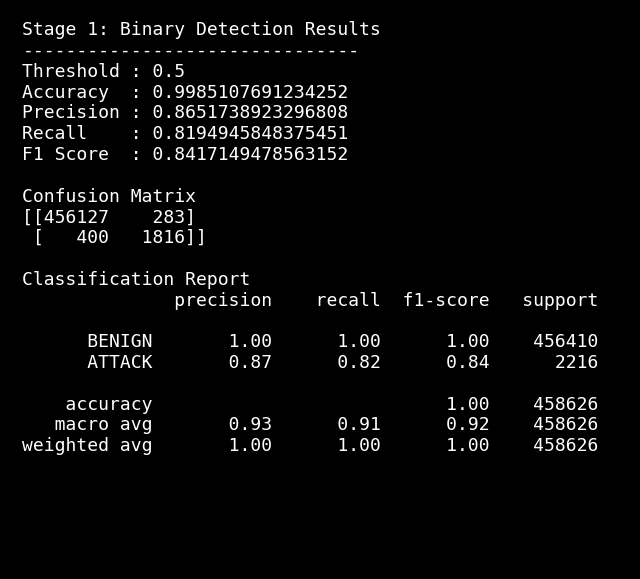

Saved image to: reports/xgboost_binary_terminal_results.png


In [2]:
import sys
import os
import textwrap

sys.path.append(r"E:\UWI\DOUEN\Douen")

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from src.config.settings import X_VALID, Y_VALID, XGBOOST_BINARY_PATH

# -------------------------------------------------
# Load validation data and model
# -------------------------------------------------
X_valid = pd.read_parquet(X_VALID)
y_valid = pd.read_parquet(Y_VALID)["Label"]

model = joblib.load(XGBOOST_BINARY_PATH)

# Convert to binary
y_true = y_valid.apply(lambda x: 0 if x == "BENIGN" else 1)
y_pred = model.predict(X_valid)

# -------------------------------------------------
# Metrics
# -------------------------------------------------
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
cm = confusion_matrix(y_true, y_pred)
report = classification_report(
    y_true,
    y_pred,
    target_names=["BENIGN", "ATTACK"],
    zero_division=0
)

# Optional threshold line just to match the old style
threshold_used = 0.5

# -------------------------------------------------
# Build terminal-style text block
# -------------------------------------------------
output_text = f"""Stage 1: Binary Detection Results
-------------------------------
Threshold : {threshold_used}
Accuracy  : {acc}
Precision : {prec}
Recall    : {rec}
F1 Score  : {f1}

Confusion Matrix
{cm}

Classification Report
{report}
"""

print(output_text)

# -------------------------------------------------
# Save as image
# -------------------------------------------------
os.makedirs("reports", exist_ok=True)

lines = output_text.splitlines()
max_len = max(len(line) for line in lines)

# size controls
fig_width = max(8, max_len * 0.11)
fig_height = max(6, len(lines) * 0.33)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")
ax.axis("off")

ax.text(
    0.02,
    0.98,
    output_text,
    va="top",
    ha="left",
    color="white",
    family="monospace",
    fontsize=13,
    transform=ax.transAxes
)

save_path = "reports/xgboost_binary_terminal_results.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print(f"Saved image to: {save_path}")